In [1]:
import shutil
import os

# Define source and destination
src = '/kaggle/input/datasets/shathaalhosayyen/dataset2'
dest = '/kaggle/working/dataset1'

# Copy the files so you can edit them
if not os.path.exists(dest):
    shutil.copytree(src, dest)
    print("Dataset copied to /kaggle/working")
else:
    print("Dataset already exists in working directory")

Dataset copied to /kaggle/working


In [2]:
dataset = '/kaggle/working/dataset1'

In [3]:
import os
import random
import shutil

# Define paths
base_path = '/kaggle/working/dataset1/ppenew.yolov11'
train_img = os.path.join(base_path, 'train/images')
train_lab = os.path.join(base_path, 'train/labels')

# Create Test and Valid folders
for split in ['valid', 'test']:
    os.makedirs(os.path.join(base_path, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(base_path, split, 'labels'), exist_ok=True)

# Get all images
images = [f for f in os.listdir(train_img) if f.endswith(('.jpg', '.png', '.jpeg'))]
random.shuffle(images)

# Calculate split sizes (e.g., 20% valid, 10% test)
val_count = int(len(images) * 0.20)
test_count = int(len(images) * 0.10)

val_files = images[:val_count]
test_files = images[val_count : val_count + test_count]

def move_files(files, split_name):
    for img_name in files:
        # Move Image
        shutil.move(os.path.join(train_img, img_name), 
                    os.path.join(base_path, split_name, 'images', img_name))
        # Move Label
        label_name = img_name.rsplit('.', 1)[0] + '.txt'
        src_label = os.path.join(train_lab, label_name)
        if os.path.exists(src_label):
            shutil.move(src_label, os.path.join(base_path, split_name, 'labels', label_name))

move_files(val_files, 'valid')
move_files(test_files, 'test')

print(f"Done! Created: \n - Valid: {len(val_files)} images \n - Test: {len(test_files)} images")

Done! Created: 
 - Valid: 3794 images 
 - Test: 1897 images


In [4]:
import os

# Define the root path 
base_path = '/kaggle/working/dataset1/ppenew.yolov11'
splits = ['train', 'valid', 'test']

print(f"{'Split':<10} | {'Number of Images'}")
print("-" * 30)

for split in splits:
    folder_path = os.path.join(base_path, split, 'images')
    if not os.path.exists(folder_path):
        folder_path = os.path.join(base_path, split)
        
    # Count only common image file extensions
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    count = len([f for f in os.listdir(folder_path) 
                 if f.lower().endswith(image_extensions)])
    
    print(f"{split.capitalize():<10} | {count}")

Split      | Number of Images
------------------------------
Train      | 13283
Valid      | 3794
Test       | 1897


In [6]:
import yaml

yaml_path = os.path.join(base_path, "data.yaml")
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

# Set the new paths
config['train'] = os.path.join(base_path, 'train/images')
config['val'] = os.path.join(base_path, 'valid/images')
config['test'] = os.path.join(base_path, 'test/images') # Adding the test set here!

with open(yaml_path, 'w') as f:
    yaml.dump(config, f)

In [7]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:0000:01


In [8]:
import os
from ultralytics import YOLO

# 1. Load the YOLO11 Nano model
model = YOLO("yolo11n.pt")

# 2. Start Training
model.train(
    data=os.path.join(dataset_path, "data.yaml"),
    epochs=50,                  
    imgsz=640,                  # Standard resolution for YOLO
    batch=16,                   # Safe for T4 GPU VRAM
    patience=10,                # Stops early if no improvement for 10 epochs
    save=True,                  # Enables checkpointing
    save_period=5,              # Saves a checkpoint file every 5 epochs
    device=0,                   # Uses the T4 GPU
    project="/kaggle/working",  # Where to save results
    name="PPE_cleaned_v2",      # Folder name for this run
    
    # Augmentations (Great for safety gear detection)
    cos_lr=True,
    augment=True,
    mosaic=1.0,
    degrees=10,
    flipud=0.3,
    fliplr=0.5,
)

print("Training Complete! Checking results on the Test set...")

# 3. Final 'Test' Evaluation 
metrics = model.val(split='test')

print(f"Final Test mAP50: {metrics.results_dict['metrics/mAP50(B)']:.4f}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dataset1/ppenew.yolov11/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102658048 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


train: Scanning /kaggle/working/dataset1/ppenew.yolov11/train/labels... 13283 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 13283/13283 535.3it/s 24.8s.1ss
train: /kaggle/working/dataset1/ppenew.yolov11/train/images/20231008_221822_jpg.rf.mWA7l3pj8Wxp3ahNIUVQ.jpg: corrupt JPEG restored and saved
train: /kaggle/working/dataset1/ppenew.yolov11/train/images/20231008_221824_jpg.rf.VbvJ1tC3AzHw2SytRj5V.jpg: corrupt JPEG restored and saved
train: /kaggle/working/dataset1/ppenew.yolov11/train/images/20231008_221833_jpg.rf.u3CNTbZg6Iy2lUBTZF9q.jpg: corrupt JPEG restored and saved
train: /kaggle/working/dataset1/ppenew.yolov11/train/images/20231008_221850_jpg.rf.uVawcpegJLmdxueHodXc.jpg: corrupt JPEG restored and saved
train: /kaggle/working/dataset1/ppenew.yolov11/train/images/20231008_221902_jpg.rf.vs1R5eBA7Kc9MMN1Irmv.jpg: corrupt JPEG restored and saved
train: /kaggle/working/dataset1/ppenew.yolov11/train/images/20231008_221904_jpg.rf.lLEGbuNhWyBvlgI9Y0x6.jpg: corrupt JPEG restored an

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (102658048 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


val: Scanning /kaggle/working/dataset1/ppenew.yolov11/test/labels... 1897 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1897/1897 388.2it/s 4.9s<0.0s
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_221848_jpg.rf.kIP6edAtudguRC306IXz.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_221856_jpg.rf.1evWlBl3ZcZeHX9ey6uf.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_222216_jpg.rf.h9igSYwG53ZMJq7fSGYs.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_223336_jpg.rf.ZveGgmY9k6WflPHkhiCb.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_223602_jpg.rf.L2jLo33jLjoqmE9ECpVL.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_223603_jpg.rf.1YTRpqVwJzCHQgzwxXrC.jpg: corrupt JPEG restored and saved
val: /kaggle/wor

In [9]:
from ultralytics import YOLO
import time
import torch

# Load  model
model = YOLO("/kaggle/working/PPE_cleaned_v2/weights/best.pt")

# Run validation
results = model.val(
    data="/kaggle/working/dataset1/ppenew.yolov11/data.yaml",
    imgsz=640,        # image size
    conf=0.15,        # same as their test
    iou=0.45,         # same as their test
    device=0,         # GPU
    plots=True,       # saves confusion matrix and curves
    save_json=True    # saves detailed results
)

# Print per-class results
print("\n" + "="*50)
print("PER-CLASS RESULTS")
print("="*50)

classes = model.names
for i, cls in classes.items():
    ap50 = results.box.ap50[i]
    ap = results.box.ap[i]
    p = results.box.p[i]
    r = results.box.r[i]
    f1 = 2 * (p * r) / (p + r + 1e-8)
    print(f"{cls:15} | P: {p:.3f} | R: {r:.3f} | F1: {f1:.3f} | mAP50: {ap50:.3f} | mAP50-95: {ap:.3f}")

# Print overall results
print("\n" + "="*50)
print("OVERALL RESULTS")
print("="*50)
print(f"Mean Precision : {results.box.mp:.3f} ({results.box.mp*100:.1f}%)")
print(f"Mean Recall    : {results.box.mr:.3f} ({results.box.mr*100:.1f}%)")
print(f"mAP @ 0.5      : {results.box.map50:.3f} ({results.box.map50*100:.1f}%)")
print(f"mAP @ 0.5:0.95 : {results.box.map:.3f} ({results.box.map*100:.1f}%)")

# Inference speed test
print("\n" + "="*50)
print("INFERENCE SPEED")
print("="*50)

import cv2
import numpy as np

test_img = np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8)
times = []

# Warmup
for _ in range(10):
    model(test_img, verbose=False)

# Actual speed test
for _ in range(100):
    start = time.time()
    model(test_img, verbose=False)
    times.append((time.time() - start) * 1000)

avg_ms = sum(times) / len(times)
fps = 1000 / avg_ms

print(f"Inference Speed : {avg_ms:.1f} ms/frame")
print(f"FPS             : {fps:.1f}")
print(f"Device          : {torch.cuda.get_device_name(0)}")
print(f"Model Size      : {sum(p.numel() for p in model.model.parameters()) * 4 / 1024**2:.1f} MB")

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2943.4±1829.6 MB/s, size: 1133.3 KB)
val: Scanning /kaggle/working/dataset1/ppenew.yolov11/valid/labels.cache... 3794 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3794/3794 1.4Git/s 0.0s
val: /kaggle/working/dataset1/ppenew.yolov11/valid/images/20231008_221835_jpg.rf.K0SvurPHypCmH3yvqKt8.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/valid/images/20231008_222024_jpg.rf.wOeIOAWHIUG2G7WNpQVR.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/valid/images/20231008_222035_jpg.rf.YSQPYvyG30DmnyrncgsC.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/valid/images/20231008_222041_jpg.rf.LrdqAGewcf9K4cRDj0nd.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppen

In [18]:
results = model.val(
    data=yaml_path,
    split="test",
    imgsz=640,
    conf=0.15,
    iou=0.45,
    device=0,
    plots=True
)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1126.0±558.8 MB/s, size: 67.2 KB)
val: Scanning /kaggle/working/dataset1/ppenew.yolov11/test/labels.cache... 1897 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1897/1897 723.3Mit/s 0.0s
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_221848_jpg.rf.kIP6edAtudguRC306IXz.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_221856_jpg.rf.1evWlBl3ZcZeHX9ey6uf.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_222216_jpg.rf.h9igSYwG53ZMJq7fSGYs.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_223336_jpg.rf.ZveGgmY9k6WflPHkhiCb.jpg: corrupt JPEG restored and saved
val: /kaggle/working/dataset1/ppenew.yolov11/test/images/20231008_223602_jpg.rf.L2jLo33jLjoqmE9ECpVL.jpg: corrupt JPEG rest

In [11]:
# Test 1 — Model loads correctly
model = YOLO("/kaggle/working/PPE_cleaned_v2/weights/best.pt")
assert model is not None
print("✅ Model loads correctly")

# Test 2 — Model detects correct classes
assert len(model.names) == 4
print(f"✅ Classes: {model.names}")

# Test 3 — Inference works
import numpy as np
test_img = np.zeros((640, 640, 3), dtype=np.uint8)
results = model(test_img)
print("✅ Inference works")

# Test 4 — Speed acceptable
import time
times = []
for _ in range(50):
    start = time.time()
    model(test_img, verbose=False)
    times.append((time.time()-start)*1000)
avg = sum(times)/len(times)
assert avg < 100  # must be under 100ms
print(f"✅ Speed: {avg:.1f}ms — Real-time capable")

✅ Model loads correctly
✅ Classes: {0: 'gloves', 1: 'goggles', 2: 'labcoat', 3: 'mask'}

0: 640x640 (no detections), 9.9ms
Speed: 1.9ms preprocess, 9.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
✅ Inference works
✅ Speed: 10.0ms — Real-time capable



image 1/1 /kaggle/working/dataset1/ppenew.yolov11/test/images/mask_aug_rot180_mask_maksssksksss339.png: 640x640 1 mask, 7.8ms
Speed: 2.3ms preprocess, 7.8ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


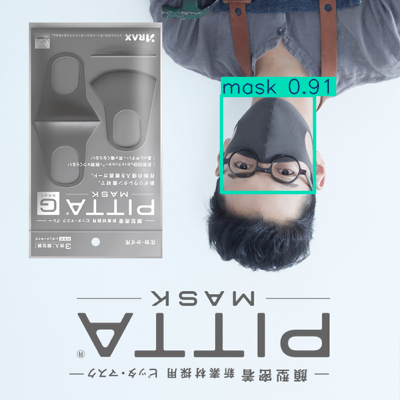

Detected: mask — Confidence: 90.9%


In [13]:
import os
from ultralytics import YOLO

model = YOLO("/kaggle/working/PPE_cleaned_v2/weights/best.pt")

# Get a test image from your dataset
test_dir = "/kaggle/working/dataset1/ppenew.yolov11/test/images/"
images = os.listdir(test_dir)

# Test on first image
test_image = f"{test_dir}/{images[0]}"
results = model(test_image, conf=0.15)
results[0].show()

for box in results[0].boxes:
    cls = model.names[int(box.cls)]
    conf = float(box.conf)
    print(f"Detected: {cls} — Confidence: {conf:.1%}")


image 1/1 /kaggle/working/dataset1/ppenew.yolov11/test/images/mask_aug_bright_mask_maksssksksss812.png: 640x640 4 masks, 7.8ms
Speed: 2.2ms preprocess, 7.8ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


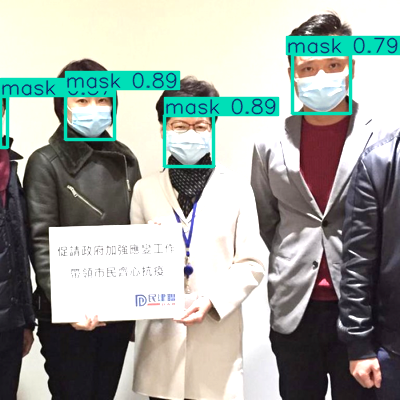

Detected: mask — Confidence: 89.2%
Detected: mask — Confidence: 89.0%
Detected: mask — Confidence: 78.6%
Detected: mask — Confidence: 37.2%


In [14]:
import os
from ultralytics import YOLO

model = YOLO("/kaggle/working/PPE_cleaned_v2/weights/best.pt")

# Get a test image from your dataset
test_dir = "/kaggle/working/dataset1/ppenew.yolov11/test/images/"
images = os.listdir(test_dir)

# Test on first image
test_image = f"{test_dir}/{images[2]}"
results = model(test_image, conf=0.15)
results[0].show()

for box in results[0].boxes:
    cls = model.names[int(box.cls)]
    conf = float(box.conf)
    print(f"Detected: {cls} — Confidence: {conf:.1%}")


image 1/1 /kaggle/working/dataset1/ppenew.yolov11/test/images/mask_maksssksksss320.png: 384x640 3 masks, 53.6ms
Speed: 1.5ms preprocess, 53.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


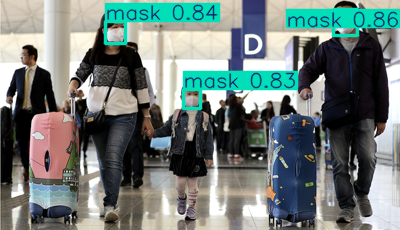

Detected: mask — Confidence: 86.2%
Detected: mask — Confidence: 83.6%
Detected: mask — Confidence: 83.1%


In [15]:
import os
from ultralytics import YOLO

model = YOLO("/kaggle/working/PPE_cleaned_v2/weights/best.pt")

# Get a test image from your dataset
test_dir = "/kaggle/working/dataset1/ppenew.yolov11/test/images/"
images = os.listdir(test_dir)

# Test on first image
test_image = f"{test_dir}/{images[10]}"
results = model(test_image, conf=0.15)
results[0].show()

for box in results[0].boxes:
    cls = model.names[int(box.cls)]
    conf = float(box.conf)
    print(f"Detected: {cls} — Confidence: {conf:.1%}")

In [21]:
import os
import random
from ultralytics import YOLO

model = YOLO("/kaggle/working/PPE_cleaned_v2/weights/best.pt")

# Path to your test images
test_img_path = "/kaggle/working/dataset1/ppenew.yolov11/test/images"

# Get all images
all_images = os.listdir(test_img_path)

# Get one image per class by checking labels
label_path = "/kaggle/working/dataset1/ppenew.yolov11/test/labels"

class_samples = {}
class_names = {0: 'gloves', 1: 'goggles', 2: 'labcoat', 3: 'mask'}

for img_file in all_images:
    label_file = img_file.rsplit('.', 1)[0] + '.txt'
    label_full = os.path.join(label_path, label_file)
    
    if os.path.exists(label_full):
        with open(label_full) as f:
            classes_in_img = [int(line.split()[0]) for line in f.readlines()]
        
        for cls_id in classes_in_img:
            cls_name = class_names.get(cls_id)
            if cls_name and cls_name not in class_samples:
                class_samples[cls_name] = os.path.join(test_img_path, img_file)
        
    if len(class_samples) == 4:
        break

# Test each class
print("="*50)
print("INDIVIDUAL IMAGE TESTING")
print("="*50)

for cls_name, img_path in class_samples.items():
    print(f"\nTesting image for class: {cls_name.upper()}")
    results = model(img_path, conf=0.15, verbose=False)
    results[0].save(f"result_{cls_name}.jpg")
    
    if len(results[0].boxes) == 0:
        print("  No detections found")
    else:
        for box in results[0].boxes:
            detected = model.names[int(box.cls)]
            conf = float(box.conf)
            print(f"  Detected: {detected} — Confidence: {conf:.1%}")

print("\n✅ Individual testing done!")
print("Check result_gloves.jpg, result_goggles.jpg, etc.")

INDIVIDUAL IMAGE TESTING

Testing image for class: MASK
  Detected: mask — Confidence: 90.9%

Testing image for class: LABCOAT
  Detected: labcoat — Confidence: 93.9%

Testing image for class: GLOVES
  Detected: gloves — Confidence: 61.2%
  Detected: gloves — Confidence: 42.0%

Testing image for class: GOGGLES
  Detected: goggles — Confidence: 89.1%

✅ Individual testing done!
Check result_gloves.jpg, result_goggles.jpg, etc.


In [22]:
print("="*50)
print("UNIT TESTING")
print("="*50)

import numpy as np

# Test 1
model_test = YOLO("/kaggle/working/PPE_cleaned_v2/weights/best.pt")
assert model_test is not None
print("✅ Test 1 — Model loads correctly")

# Test 2
assert len(model_test.names) == 4
print(f"✅ Test 2 — Correct number of classes: {len(model_test.names)}")

# Test 3
expected = ['gloves', 'goggles', 'labcoat', 'mask']
assert list(model_test.names.values()) == expected
print(f"✅ Test 3 — Correct class names: {expected}")

# Test 4
dummy = np.zeros((640, 640, 3), dtype=np.uint8)
res = model_test(dummy, verbose=False)
assert res is not None
print("✅ Test 4 — Inference runs without errors")

# Test 5
import time
times = []
for _ in range(30):
    start = time.time()
    model_test(dummy, verbose=False)
    times.append((time.time()-start)*1000)
avg = sum(times)/len(times)
assert avg < 100
print(f"✅ Test 5 — Real-time speed confirmed: {avg:.1f}ms")

print("\n✅ ALL UNIT TESTS PASSED")

UNIT TESTING
✅ Test 1 — Model loads correctly
✅ Test 2 — Correct number of classes: 4
✅ Test 3 — Correct class names: ['gloves', 'goggles', 'labcoat', 'mask']
✅ Test 4 — Inference runs without errors
✅ Test 5 — Real-time speed confirmed: 9.9ms

✅ ALL UNIT TESTS PASSED
